In [4]:
import os
import numpy as np
import pandas as pd

In [5]:
DATA_DIR = "/kaggle/input/competitions/task-1-clickbait-detection-mse-641-s-26"

train_df = pd.read_json(f"{DATA_DIR}/train.jsonl", lines=True)
val_df = pd.read_json(f"{DATA_DIR}/val.jsonl", lines=True)
test_df = pd.read_json(f"{DATA_DIR}/test.jsonl", lines=True)
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_solution.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (3200, 14)
Validation: (400, 14)
Test: (400, 10)


In [6]:
print(train_df.columns.tolist())
display(train_df.head(1))

print("\nClass distribution:")
print(train_df["tags"].value_counts())

['uuid', 'postId', 'postText', 'postPlatform', 'targetParagraphs', 'targetTitle', 'targetDescription', 'targetKeywords', 'targetMedia', 'targetUrl', 'provenance', 'spoiler', 'spoilerPositions', 'tags']


,uuid,postId,postText,postPlatform,targetParagraphs,targetTitle,targetDescription,targetKeywords,targetMedia,targetUrl,provenance,spoiler,spoilerPositions,tags
0,0af11f6b-c889-4520-9372-66ba25cb7657,532quh,"[Wes Welker Wanted Dinner With Tom Brady, But ...",reddit,[It’ll be just like old times this weekend for...,"Wes Welker Wanted Dinner With Tom Brady, But P...",It'll be just like old times this weekend for ...,"new england patriots, ricky doyle, top stories,","[http://pixel.wp.com/b.gif?v=noscript, http://...",http://nesn.com/2016/09/wes-welker-wanted-dinn...,"{'source': 'anonymized', 'humanSpoiler': 'They...",[how about that morning we go throw?],"[[[3, 151], [3, 186]]]",[passage]



Class distribution:
tags
[phrase]     1367
[passage]    1274
[multi]       559
Name: count, dtype: int64


In [7]:
for df in [train_df, val_df]:
    df["label"] = df["tags"].apply(lambda x: x[0])

for df in [train_df, val_df, test_df]:
    df["post_text"] = df["postText"].apply(lambda x: " ".join(x))

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

In [9]:
model_lr = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [10]:
model_lr.fit(train_df["post_text"], train_df["label"])

val_pred_lr = model_lr.predict(val_df["post_text"])

print(
    "Macro F1:",
    f1_score(val_df["label"], val_pred_lr, average="macro")
)

print(
    "Weighted F1:",
    f1_score(val_df["label"], val_pred_lr, average="weighted")
)

print("\nClassification Report:")
print(
    classification_report(
        val_df["label"],
        val_pred_lr,
        digits=4
    )
)

Macro F1: 0.5782310425881305
Weighted F1: 0.5958932365915615

Classification Report:
              precision    recall  f1-score   support

       multi     0.5065    0.4643    0.4845        84
     passage     0.6216    0.5974    0.6093       154
      phrase     0.6171    0.6667    0.6409       162

    accuracy                         0.5975       400
   macro avg     0.5818    0.5761    0.5782       400
weighted avg     0.5956    0.5975    0.5959       400



In [11]:
# Linear SVM

from sklearn.svm import LinearSVC

model_svm = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            random_state=42
        )
    )
])

model_svm.fit(train_df["post_text"], train_df["label"])

val_pred_svm = model_svm.predict(val_df["post_text"])

print(
    "Macro F1:",
    f1_score(val_df["label"], val_pred_svm, average="macro")
)

print(
    "Weighted F1:",
    f1_score(val_df["label"], val_pred_svm, average="weighted")
)

print("\nClassification Report:")
print(
    classification_report(
        val_df["label"],
        val_pred_svm,
        digits=4
    )
)

Macro F1: 0.5786545831168438
Weighted F1: 0.5951128554551228

Classification Report:
              precision    recall  f1-score   support

       multi     0.5806    0.4286    0.4932        84
     passage     0.6014    0.5779    0.5894       154
      phrase     0.6053    0.7099    0.6534       162

    accuracy                         0.6000       400
   macro avg     0.5958    0.5721    0.5787       400
weighted avg     0.5986    0.6000    0.5951       400



In [12]:
# Create a new input that combines the clickbait post and article title
train_df["post_title_text"] = (
    train_df["post_text"] + " " + train_df["targetTitle"].fillna("")
)

val_df["post_title_text"] = (
    val_df["post_text"] + " " + val_df["targetTitle"].fillna("")
)

test_df["post_title_text"] = (
    test_df["post_text"] + " " + test_df["targetTitle"].fillna("")
)

# Build a new Logistic Regression model for the combined text
model_lr_title = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])


model_lr_title.fit(
    train_df["post_title_text"],
    train_df["label"]
)


val_pred_lr_title = model_lr_title.predict(
    val_df["post_title_text"]
)

print(
    "Macro F1:",
    f1_score(
        val_df["label"],
        val_pred_lr_title,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        val_df["label"],
        val_pred_lr_title,
        average="weighted"
    )
)

print("\nClassification Report:")
print(
    classification_report(
        val_df["label"],
        val_pred_lr_title,
        digits=4
    )
)

Macro F1: 0.5712460857895522
Weighted F1: 0.5853097569461704

Classification Report:
              precision    recall  f1-score   support

       multi     0.5125    0.4881    0.5000        84
     passage     0.5887    0.5390    0.5627       154
      phrase     0.6201    0.6852    0.6510       162

    accuracy                         0.5875       400
   macro avg     0.5738    0.5707    0.5712       400
weighted avg     0.5854    0.5875    0.5853       400



In [13]:
from sklearn.model_selection import ParameterGrid

results = []

for C_value in [0.1, 0.5, 1.0, 2.0, 5.0]:
    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=30000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LinearSVC(
                C=C_value,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    model.fit(train_df["post_text"], train_df["label"])
    predictions = model.predict(val_df["post_text"])

    macro_f1 = f1_score(
        val_df["label"],
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        val_df["label"],
        predictions,
        average="weighted"
    )

    results.append({
        "C": C_value,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("Macro F1", ascending=False))

,C,Macro F1,Weighted F1
0,0.1,0.587969,0.605065
3,2.0,0.580861,0.596458
2,1.0,0.578655,0.595113
1,0.5,0.574951,0.593996
4,5.0,0.550637,0.564728


In [14]:
best_svm = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=0.1,
            class_weight="balanced",
            random_state=42
        )
    )
])

best_svm.fit(
    train_df["post_text"],
    train_df["label"]
)

val_pred_best_svm = best_svm.predict(
    val_df["post_text"]
)

print(
    "Macro F1:",
    f1_score(
        val_df["label"],
        val_pred_best_svm,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        val_df["label"],
        val_pred_best_svm,
        average="weighted"
    )
)

print("\nClassification Report:")
print(
    classification_report(
        val_df["label"],
        val_pred_best_svm,
        digits=4
    )
)

Macro F1: 0.5879688404594843
Weighted F1: 0.6050654871975

Classification Report:
              precision    recall  f1-score   support

       multi     0.6140    0.4167    0.4965        84
     passage     0.6275    0.6234    0.6254       154
      phrase     0.5947    0.6975    0.6420       162

    accuracy                         0.6100       400
   macro avg     0.6121    0.5792    0.5880       400
weighted avg     0.6114    0.6100    0.6051       400



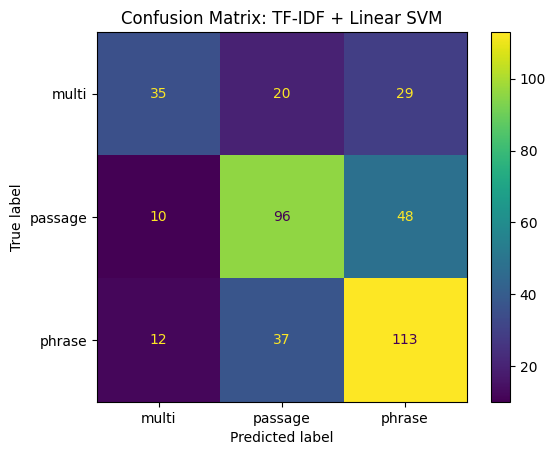

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["multi", "passage", "phrase"]

cm = confusion_matrix(
    val_df["label"],
    val_pred_best_svm,
    labels=labels
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

display_matrix.plot()
plt.title("Confusion Matrix: TF-IDF + Linear SVM")
plt.show()

In [16]:
import re
from scipy.sparse import hstack, csr_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class StructuralFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []

        for text in X:
            text_lower = text.lower()

            word_count = len(text.split())
            digit_count = sum(char.isdigit() for char in text)
            question_marks = text.count("?")
            exclamation_marks = text.count("!")

            list_words = [
                "reasons", "things", "ways", "habits",
                "signs", "facts", "tips", "steps"
            ]

            contains_list_word = int(
                any(word in text_lower for word in list_words)
            )

            contains_number = int(
                bool(re.search(r"\d+", text))
            )

            features.append([
                word_count,
                digit_count,
                question_marks,
                exclamation_marks,
                contains_list_word,
                contains_number
            ])

        return csr_matrix(features)


tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(train_df["post_text"])
X_val_tfidf = tfidf.transform(val_df["post_text"])

structural = StructuralFeatures()

X_train_struct = structural.fit_transform(train_df["post_text"])
X_val_struct = structural.transform(val_df["post_text"])

X_train_combined = hstack([
    X_train_tfidf,
    X_train_struct
])

X_val_combined = hstack([
    X_val_tfidf,
    X_val_struct
])

model_svm_features = LinearSVC(
    C=0.1,
    class_weight="balanced",
    max_iter = 10000,
    random_state=42
)

model_svm_features.fit(
    X_train_combined,
    train_df["label"]
)

val_pred_svm_features = model_svm_features.predict(
    X_val_combined
)

print(
    "Macro F1:",
    f1_score(
        val_df["label"],
        val_pred_svm_features,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        val_df["label"],
        val_pred_svm_features,
        average="weighted"
    )
)

print("\nClassification Report:")
print(
    classification_report(
        val_df["label"],
        val_pred_svm_features,
        digits=4
    )
)

Macro F1: 0.5956858504310953
Weighted F1: 0.6077831964713308

Classification Report:
              precision    recall  f1-score   support

       multi     0.6727    0.4405    0.5324        84
     passage     0.6338    0.5844    0.6081       154
      phrase     0.5813    0.7284    0.6466       162

    accuracy                         0.6125       400
   macro avg     0.6293    0.5844    0.5957       400
weighted avg     0.6207    0.6125    0.6078       400



In [17]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [18]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset
from sklearn.preprocessing import LabelEncoder

In [19]:
# Map the three class names to numerical labels
label2id = {
    "multi": 0,
    "passage": 1,
    "phrase": 2
}

id2label = {
    0: "multi",
    1: "passage",
    2: "phrase"
}

# Create small DataFrames containing only the model input and label
train_bert_df = pd.DataFrame({
    "text": train_df["post_text"],
    "label": train_df["label"].map(label2id)
})

val_bert_df = pd.DataFrame({
    "text": val_df["post_text"],
    "label": val_df["label"].map(label2id)
})

# Convert Pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(
    train_bert_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_bert_df,
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print("\nFirst training example:")
print(train_dataset[0])

Dataset({
    features: ['text', 'label'],
    num_rows: 3200
})
Dataset({
    features: ['text', 'label'],
    num_rows: 400
})

First training example:
{'text': 'Wes Welker Wanted Dinner With Tom Brady, But Patriots QB Had Better Idea', 'label': 1}


In [20]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_batch,
    batched=True
)

tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

print(tokenized_train)
print("\nTokenized first example:")
print(tokenized_train[0])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3200
})

Tokenized first example:
{'label': tensor(1), 'input_ids': tensor([  101, 14008,  2057, 28143,  2099,  2359,  4596,  2007,  3419, 10184,
         1010,  2021, 11579, 26171,  2018,  2488,  2801,   102,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 

In [21]:
# DistilBERT does not use token_type_ids
if "token_type_ids" in tokenized_train.column_names:
    tokenized_train = tokenized_train.remove_columns(["token_type_ids"])
    tokenized_val = tokenized_val.remove_columns(["token_type_ids"])

print(tokenized_train)

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3200
})


In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    f1_weighted = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
training_args = TrainingArguments(
    output_dir="./distilbert_task1_results",

    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    num_train_epochs=4,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",

    fp16=True,
    seed=42
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("Trainer is ready.")

Trainer is ready.


In [24]:
training_output = trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,2.000848,1.895741,0.527500,0.358667,0.443456,0.391437,0.464148
2,1.733237,1.643938,0.655000,0.736173,0.609120,0.626567,0.644743
3,1.533691,1.524728,0.695000,0.724545,0.661055,0.676270,0.690244
4,1.427258,1.510487,0.687500,0.727351,0.654348,0.671751,0.683313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [25]:
bert_eval_results = trainer.evaluate()

print("Final validation results:")
for metric, value in bert_eval_results.items():
    print(f"{metric}: {value}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final validation results:
eval_loss: 1.52472722530365
eval_accuracy: 0.695
eval_macro_precision: 0.7245454907109042
eval_macro_recall: 0.6610549943883277
eval_macro_f1: 0.6762704354888408
eval_weighted_f1: 0.6902436095092886
eval_runtime: 0.4999
eval_samples_per_second: 800.179
eval_steps_per_second: 8.002
epoch: 4.0


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT Classification Report:
              precision    recall  f1-score   support

       multi     0.8163    0.4762    0.6015        84
     passage     0.6556    0.7662    0.7066       154
      phrase     0.7018    0.7407    0.7207       162

    accuracy                         0.6950       400
   macro avg     0.7245    0.6611    0.6763       400
weighted avg     0.7080    0.6950    0.6902       400



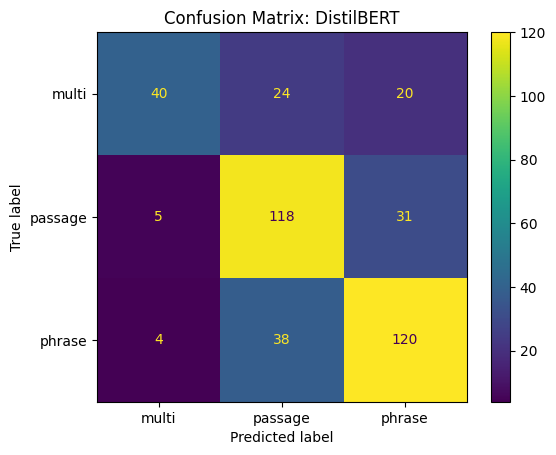

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get validation predictions from the best DistilBERT checkpoint
prediction_output = trainer.predict(tokenized_val)

bert_logits = prediction_output.predictions
bert_pred_ids = np.argmax(bert_logits, axis=-1)

bert_true_ids = val_bert_df["label"].to_numpy()

bert_pred_labels = [id2label[i] for i in bert_pred_ids]
bert_true_labels = [id2label[i] for i in bert_true_ids]

print("DistilBERT Classification Report:")
print(
    classification_report(
        bert_true_labels,
        bert_pred_labels,
        labels=["multi", "passage", "phrase"],
        digits=4
    )
)

cm_bert = confusion_matrix(
    bert_true_labels,
    bert_pred_labels,
    labels=["multi", "passage", "phrase"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bert,
    display_labels=["multi", "passage", "phrase"]
).plot()

plt.title("Confusion Matrix: DistilBERT")
plt.show()

In [27]:
test_bert_df = pd.DataFrame({
    "text": test_df["post_text"]
})

test_dataset = Dataset.from_pandas(
    test_bert_df,
    preserve_index=False
)

tokenized_test = test_dataset.map(
    tokenize_batch,
    batched=True
)

tokenized_test = tokenized_test.remove_columns(["text"])

if "token_type_ids" in tokenized_test.column_names:
    tokenized_test = tokenized_test.remove_columns(["token_type_ids"])

tokenized_test.set_format("torch")

print(tokenized_test)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 400
})


In [28]:
# Generate test predictions using the best loaded checkpoint
test_prediction_output = trainer.predict(tokenized_test)

test_logits = test_prediction_output.predictions
test_pred_ids = np.argmax(test_logits, axis=-1)

# Convert numerical predictions back to class names
test_pred_labels = [id2label[i] for i in test_pred_ids]

# Use the sample submission to guarantee the correct format
submission_distilbert = sample_submission.copy()
submission_distilbert["spoilerType"] = test_pred_labels

submission_path = "/kaggle/working/distilbert_task1_submission.csv"
submission_distilbert.to_csv(submission_path, index=False)

print("Submission shape:", submission_distilbert.shape)
print("\nPredicted class distribution:")
print(submission_distilbert["spoilerType"].value_counts())

display(submission_distilbert.head(10))

print("\nSaved to:", submission_path)

Submission shape: (400, 2)

Predicted class distribution:
spoilerType
passage    196
phrase     169
multi       35
Name: count, dtype: int64


,id,spoilerType
0,0,passage
1,1,passage
2,2,phrase
3,3,phrase
4,4,passage
5,5,phrase
6,6,passage
7,7,passage
8,8,phrase
9,9,passage



Saved to: /kaggle/working/distilbert_task1_submission.csv


In [29]:
## RoBERTa base

ROBERTA_MODEL_NAME = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    ROBERTA_MODEL_NAME
)

def tokenize_roberta(batch):
    return roberta_tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

roberta_train = train_dataset.map(
    tokenize_roberta,
    batched=True
)

roberta_val = val_dataset.map(
    tokenize_roberta,
    batched=True
)

roberta_train = roberta_train.remove_columns(["text"])
roberta_val = roberta_val.remove_columns(["text"])

roberta_train.set_format("torch")
roberta_val.set_format("torch")

print(roberta_train)
print(roberta_val)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3200
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 400
})


In [30]:
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
roberta_training_args = TrainingArguments(
    output_dir="./roberta_task1_results",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=4,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",

    fp16=True,
    seed=42
)

In [33]:
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train,
    eval_dataset=roberta_val,
    compute_metrics=compute_metrics
)

print("RoBERTa trainer is ready.")

RoBERTa trainer is ready.


In [34]:
roberta_training_output = roberta_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.934501,1.541026,0.682500,0.711308,0.654468,0.669221,0.678249
2,1.467185,1.363523,0.722500,0.766361,0.692935,0.709002,0.718517
3,1.210554,1.388848,0.722500,0.753259,0.702060,0.715883,0.720393
4,1.012812,1.386351,0.722500,0.731431,0.703436,0.712375,0.720729


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [35]:
roberta_eval_results = roberta_trainer.evaluate()

print("RoBERTa validation results:")
for metric, value in roberta_eval_results.items():
    print(f"{metric}: {value}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


RoBERTa validation results:
eval_loss: 1.3886401653289795
eval_accuracy: 0.7225
eval_macro_precision: 0.7532586799383814
eval_macro_recall: 0.7020602853936188
eval_macro_f1: 0.7158830625577716
eval_weighted_f1: 0.7203928700120634
eval_runtime: 1.061
eval_samples_per_second: 377.0
eval_steps_per_second: 6.598
epoch: 4.0


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


RoBERTa Classification Report:
              precision    recall  f1-score   support

       multi     0.8448    0.5833    0.6901        84
     passage     0.6649    0.8377    0.7414       154
      phrase     0.7500    0.6852    0.7161       162

    accuracy                         0.7225       400
   macro avg     0.7533    0.7021    0.7159       400
weighted avg     0.7372    0.7225    0.7204       400



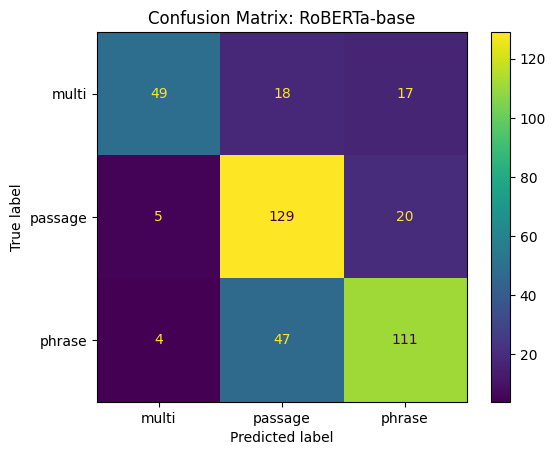

In [36]:
roberta_prediction_output = roberta_trainer.predict(roberta_val)

roberta_logits = roberta_prediction_output.predictions
roberta_pred_ids = np.argmax(roberta_logits, axis=-1)

roberta_true_ids = val_bert_df["label"].to_numpy()

roberta_pred_labels = [id2label[i] for i in roberta_pred_ids]
roberta_true_labels = [id2label[i] for i in roberta_true_ids]

print("RoBERTa Classification Report:")
print(
    classification_report(
        roberta_true_labels,
        roberta_pred_labels,
        labels=["multi", "passage", "phrase"],
        digits=4
    )
)

cm_roberta = confusion_matrix(
    roberta_true_labels,
    roberta_pred_labels,
    labels=["multi", "passage", "phrase"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_roberta,
    display_labels=["multi", "passage", "phrase"]
).plot()

plt.title("Confusion Matrix: RoBERTa-base")
plt.show()

In [37]:
roberta_test = test_dataset.map(
    tokenize_roberta,
    batched=True
)

roberta_test = roberta_test.remove_columns(["text"])

if "token_type_ids" in roberta_test.column_names:
    roberta_test = roberta_test.remove_columns(["token_type_ids"])

roberta_test.set_format("torch")

roberta_test_output = roberta_trainer.predict(roberta_test)

roberta_test_logits = roberta_test_output.predictions
roberta_test_pred_ids = np.argmax(roberta_test_logits, axis=-1)
roberta_test_labels = [id2label[i] for i in roberta_test_pred_ids]

submission_roberta = sample_submission.copy()
submission_roberta["spoilerType"] = roberta_test_labels

roberta_submission_path = (
    "/kaggle/working/roberta_base_task1_submission.csv"
)

submission_roberta.to_csv(
    roberta_submission_path,
    index=False
)

print("Submission shape:", submission_roberta.shape)

print("\nPredicted class distribution:")
print(submission_roberta["spoilerType"].value_counts())

display(submission_roberta.head(10))

print("\nSaved to:", roberta_submission_path)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Submission shape: (400, 2)

Predicted class distribution:
spoilerType
passage    204
phrase     148
multi       48
Name: count, dtype: int64


,id,spoilerType
0,0,phrase
1,1,passage
2,2,phrase
3,3,phrase
4,4,passage
5,5,phrase
6,6,multi
7,7,passage
8,8,phrase
9,9,multi



Saved to: /kaggle/working/roberta_base_task1_submission.csv


In [44]:
## Adding class weighted to the previous

import torch
from torch import nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            raise ValueError("class_weights must be provided.")

        self.class_weights = torch.tensor(
            class_weights,
            dtype=torch.float
        )

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_function = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        # Use the logits shape instead of model.config,
        # which also works when the model is wrapped in DataParallel
        loss = loss_function(
            logits.reshape(-1, logits.shape[-1]),
            labels.reshape(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [45]:
weighted_roberta_trainer = WeightedTrainer(
    model=weighted_roberta_model,
    args=weighted_roberta_args,
    train_dataset=roberta_train,
    eval_dataset=roberta_val,
    compute_metrics=compute_metrics,
    class_weights=[1.5, 1.0, 1.0]
)

In [46]:
weighted_roberta_output = weighted_roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.012065,0.802925,0.655000,0.671993,0.641922,0.652979,0.654772
2,0.780166,0.709022,0.720000,0.737526,0.698399,0.711548,0.718443
3,0.638544,0.735429,0.710000,0.728991,0.693469,0.702606,0.708280
4,0.528348,0.744311,0.702500,0.707557,0.688779,0.693314,0.701303


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Class-Weighted RoBERTa Classification Report:
              precision    recall  f1-score   support

       multi     0.8033    0.5833    0.6759        84
     passage     0.6867    0.7403    0.7125       154
      phrase     0.7168    0.7654    0.7403       162

    accuracy                         0.7175       400
   macro avg     0.7356    0.6963    0.7096       400
weighted avg     0.7234    0.7175    0.7161       400



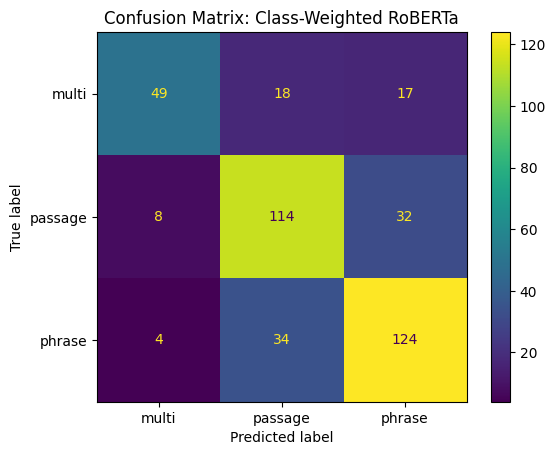

In [47]:
weighted_prediction_output = weighted_roberta_trainer.predict(roberta_val)

weighted_logits = weighted_prediction_output.predictions
weighted_pred_ids = np.argmax(weighted_logits, axis=-1)

weighted_true_ids = val_bert_df["label"].to_numpy()

weighted_pred_labels = [
    id2label[i] for i in weighted_pred_ids
]

weighted_true_labels = [
    id2label[i] for i in weighted_true_ids
]

print("Class-Weighted RoBERTa Classification Report:")
print(
    classification_report(
        weighted_true_labels,
        weighted_pred_labels,
        labels=["multi", "passage", "phrase"],
        digits=4
    )
)

weighted_cm = confusion_matrix(
    weighted_true_labels,
    weighted_pred_labels,
    labels=["multi", "passage", "phrase"]
)

ConfusionMatrixDisplay(
    confusion_matrix=weighted_cm,
    display_labels=["multi", "passage", "phrase"]
).plot()

plt.title("Confusion Matrix: Class-Weighted RoBERTa")
plt.show()

In [48]:
train_title_df = pd.DataFrame({
    "post": train_df["post_text"],
    "title": train_df["targetTitle"].fillna(""),
    "label": train_df["label"].map(label2id)
})

val_title_df = pd.DataFrame({
    "post": val_df["post_text"],
    "title": val_df["targetTitle"].fillna(""),
    "label": val_df["label"].map(label2id)
})

train_title_dataset = Dataset.from_pandas(
    train_title_df,
    preserve_index=False
)

val_title_dataset = Dataset.from_pandas(
    val_title_df,
    preserve_index=False
)

In [49]:
def tokenize_roberta_title(batch):
    return roberta_tokenizer(
        batch["post"],
        batch["title"],
        truncation=True,
        padding="max_length",
        max_length=96
    )

roberta_title_train = train_title_dataset.map(
    tokenize_roberta_title,
    batched=True
)

roberta_title_val = val_title_dataset.map(
    tokenize_roberta_title,
    batched=True
)

roberta_title_train = roberta_title_train.remove_columns([
    "post",
    "title"
])

roberta_title_val = roberta_title_val.remove_columns([
    "post",
    "title"
])

roberta_title_train.set_format("torch")
roberta_title_val.set_format("torch")

print(roberta_title_train)

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3200
})


In [50]:
roberta_title_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [51]:
roberta_title_args = TrainingArguments(
    output_dir="./roberta_title_task1_results",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=4,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",

    fp16=True,
    seed=42
)

roberta_title_trainer = Trainer(
    model=roberta_title_model,
    args=roberta_title_args,
    train_dataset=roberta_title_train,
    eval_dataset=roberta_title_val,
    compute_metrics=compute_metrics
)

In [52]:
roberta_title_trainer.train()

roberta_title_results = roberta_title_trainer.evaluate()

print("RoBERTa post + title validation results:")
for metric, value in roberta_title_results.items():
    print(f"{metric}: {value}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.954933,1.583629,0.677500,0.683731,0.648549,0.658306,0.672714
2,1.462566,1.410139,0.717500,0.748684,0.684571,0.699177,0.712348
3,1.180795,1.405297,0.722500,0.736688,0.705561,0.714705,0.721030
4,0.952759,1.447547,0.727500,0.732658,0.713177,0.719852,0.726402


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RoBERTa post + title validation results:
eval_loss: 1.447547435760498
eval_accuracy: 0.7275
eval_macro_precision: 0.7326576916150486
eval_macro_recall: 0.7131767409545188
eval_macro_f1: 0.7198524870311619
eval_weighted_f1: 0.7264018846948156
eval_runtime: 1.556
eval_samples_per_second: 257.067
eval_steps_per_second: 4.499
epoch: 4.0


In [53]:
roberta_title_prediction_output = roberta_title_trainer.predict(
    roberta_title_val
)

roberta_title_logits = roberta_title_prediction_output.predictions
roberta_title_pred_ids = np.argmax(roberta_title_logits, axis=-1)

roberta_title_true_ids = val_title_df["label"].to_numpy()

roberta_title_pred_labels = [
    id2label[i] for i in roberta_title_pred_ids
]

roberta_title_true_labels = [
    id2label[i] for i in roberta_title_true_ids
]

print("RoBERTa Post + Title Classification Report:")
print(
    classification_report(
        roberta_title_true_labels,
        roberta_title_pred_labels,
        labels=["multi", "passage", "phrase"],
        digits=4
    )
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


RoBERTa Post + Title Classification Report:
              precision    recall  f1-score   support

       multi     0.7465    0.6310    0.6839        84
     passage     0.6949    0.7987    0.7432       154
      phrase     0.7566    0.7099    0.7325       162

    accuracy                         0.7275       400
   macro avg     0.7327    0.7132    0.7199       400
weighted avg     0.7307    0.7275    0.7264       400



In [54]:
test_title_df = pd.DataFrame({
    "post": test_df["post_text"],
    "title": test_df["targetTitle"].fillna("")
})

test_title_dataset = Dataset.from_pandas(
    test_title_df,
    preserve_index=False
)

roberta_title_test = test_title_dataset.map(
    tokenize_roberta_title,
    batched=True
)

roberta_title_test = roberta_title_test.remove_columns([
    "post",
    "title"
])

roberta_title_test.set_format("torch")

roberta_title_test_output = roberta_title_trainer.predict(
    roberta_title_test
)

roberta_title_test_logits = roberta_title_test_output.predictions
roberta_title_test_pred_ids = np.argmax(
    roberta_title_test_logits,
    axis=-1
)

roberta_title_test_labels = [
    id2label[i] for i in roberta_title_test_pred_ids
]

submission_roberta_title = sample_submission.copy()
submission_roberta_title["spoilerType"] = roberta_title_test_labels

roberta_title_submission_path = (
    "/kaggle/working/roberta_post_title_task1_submission.csv"
)

submission_roberta_title.to_csv(
    roberta_title_submission_path,
    index=False
)

print("Submission shape:", submission_roberta_title.shape)
print(submission_roberta_title["spoilerType"].value_counts())
display(submission_roberta_title.head())

print("Saved to:", roberta_title_submission_path)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Submission shape: (400, 2)
spoilerType
passage    201
phrase     147
multi       52
Name: count, dtype: int64


,id,spoilerType
0,0,phrase
1,1,passage
2,2,phrase
3,3,phrase
4,4,passage


Saved to: /kaggle/working/roberta_post_title_task1_submission.csv


In [55]:
import torch.nn.functional as F

# Convert validation logits to probabilities
post_probs = F.softmax(
    torch.tensor(roberta_logits),
    dim=1
).numpy()

title_probs = F.softmax(
    torch.tensor(roberta_title_logits),
    dim=1
).numpy()

ensemble_results = []

# Weight assigned to the stronger post-only model
for post_weight in [0.5, 0.6, 0.7, 0.8, 0.9]:
    title_weight = 1.0 - post_weight

    combined_probs = (
        post_weight * post_probs
        + title_weight * title_probs
    )

    combined_pred_ids = np.argmax(combined_probs, axis=1)

    macro_f1 = f1_score(
        roberta_true_ids,
        combined_pred_ids,
        average="macro"
    )

    weighted_f1 = f1_score(
        roberta_true_ids,
        combined_pred_ids,
        average="weighted"
    )

    ensemble_results.append({
        "post_weight": post_weight,
        "title_weight": title_weight,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

ensemble_results_df = pd.DataFrame(ensemble_results)

display(
    ensemble_results_df.sort_values(
        "macro_f1",
        ascending=False
    )
)

,post_weight,title_weight,macro_f1,weighted_f1
1,0.6,0.4,0.725276,0.730949
0,0.5,0.5,0.722588,0.728790
2,0.7,0.3,0.720560,0.727787
3,0.8,0.2,0.713435,0.720147
4,0.9,0.1,0.712190,0.717804


In [57]:
import torch.nn.functional as F

# Convert test logits from both RoBERTa models into probabilities
post_test_probs = F.softmax(
    torch.tensor(roberta_test_logits),
    dim=1
).numpy()

title_test_probs = F.softmax(
    torch.tensor(roberta_title_test_logits),
    dim=1
).numpy()

ensemble_test_probs = (
    0.6 * post_test_probs
    + 0.4 * title_test_probs
)

ensemble_test_pred_ids = np.argmax(
    ensemble_test_probs,
    axis=1
)

ensemble_test_labels = [
    id2label[i] for i in ensemble_test_pred_ids
]

# Create submission
submission_ensemble = sample_submission.copy()
submission_ensemble["spoilerType"] = ensemble_test_labels

ensemble_submission_path = (
    "/kaggle/working/roberta_ensemble_60_40_task1.csv"
)

submission_ensemble.to_csv(
    ensemble_submission_path,
    index=False
)

print("Submission shape:", submission_ensemble.shape)

print("\nPredicted class distribution:")
print(submission_ensemble["spoilerType"].value_counts())

display(submission_ensemble.head(10))

print("\nSaved to:", ensemble_submission_path)

Submission shape: (400, 2)

Predicted class distribution:
spoilerType
passage    200
phrase     148
multi       52
Name: count, dtype: int64


,id,spoilerType
0,0,phrase
1,1,passage
2,2,phrase
3,3,phrase
4,4,passage
5,5,phrase
6,6,multi
7,7,passage
8,8,phrase
9,9,multi



Saved to: /kaggle/working/roberta_ensemble_60_40_task1.csv


In [58]:
# DeBERTa base

DEBERTA_MODEL_NAME = "microsoft/deberta-v3-base"

deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_MODEL_NAME
)

def tokenize_deberta(batch):
    return deberta_tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

deberta_train = train_dataset.map(
    tokenize_deberta,
    batched=True
)

deberta_val = val_dataset.map(
    tokenize_deberta,
    batched=True
)

deberta_train = deberta_train.remove_columns(["text"])
deberta_val = deberta_val.remove_columns(["text"])

if "token_type_ids" in deberta_train.column_names:
    deberta_train = deberta_train.remove_columns(["token_type_ids"])
    deberta_val = deberta_val.remove_columns(["token_type_ids"])

deberta_train.set_format("torch")
deberta_val.set_format("torch")

print(deberta_train)
print(deberta_val)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3200
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 400
})


In [64]:
deberta_model_fp32 = AutoModelForSequenceClassification.from_pretrained(
    DEBERTA_MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)

deberta_model_fp32 = deberta_model_fp32.float()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

In [65]:
deberta_training_args_fp32 = TrainingArguments(
    output_dir="./deberta_task1_results_fp32",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=4,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",

    fp16=False,
    bf16=False,
    seed=42
)

In [66]:
deberta_trainer_fp32 = Trainer(
    model=deberta_model_fp32,
    args=deberta_training_args_fp32,
    train_dataset=deberta_train,
    eval_dataset=deberta_val,
    compute_metrics=compute_metrics
)

print("FP32 DeBERTa trainer is ready.")

FP32 DeBERTa trainer is ready.


In [67]:
deberta_training_output_fp32 = deberta_trainer_fp32.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,2.079959,2.096859,0.405000,0.135000,0.333333,0.192171,0.233488
2,2.002940,2.012405,0.522500,0.347622,0.443188,0.386152,0.456461
3,1.848429,1.949114,0.527500,0.685508,0.448773,0.406574,0.472822
4,1.690909,1.962054,0.570000,0.620112,0.518251,0.523283,0.553041


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

In [68]:
deberta_eval_results_fp32 = deberta_trainer_fp32.evaluate()

print("DeBERTa validation results:")
for metric, value in deberta_eval_results_fp32.items():
    print(f"{metric}: {value}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DeBERTa validation results:
eval_loss: 1.9620544910430908
eval_accuracy: 0.57
eval_macro_precision: 0.6201120388210947
eval_macro_recall: 0.5182512960290738
eval_macro_f1: 0.5232829768285189
eval_weighted_f1: 0.5530414823561968
eval_runtime: 1.8985
eval_samples_per_second: 210.689
eval_steps_per_second: 6.847
epoch: 4.0


In [73]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def train_roberta_with_seed(seed):
    model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_MODEL_NAME,
        num_labels=3,
        label2id=label2id,
        id2label=id2label
    )

    args = TrainingArguments(
        output_dir=f"./roberta_seed_{seed}",

        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,

        num_train_epochs=4,
        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",

        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        save_total_limit=1,
        report_to="none",

        fp16=True,
        seed=seed,
        data_seed=seed
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=roberta_train,
        eval_dataset=roberta_val,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()

    print(f"\nSeed {seed} results:")
    for metric, value in results.items():
        print(f"{metric}: {value}")

    return trainer, results

In [74]:
roberta_trainer_seed7, results_seed7 = train_roberta_with_seed(7)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along d

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.969141,1.618588,0.665000,0.732989,0.633384,0.655455,0.662163
2,1.486129,1.408203,0.715000,0.747164,0.693549,0.708480,0.713586
3,1.224827,1.451314,0.720000,0.736387,0.705507,0.716998,0.719333
4,1.002885,1.518271,0.712500,0.727930,0.699548,0.710406,0.712250


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Seed 7 results:
eval_loss: 1.4515652656555176
eval_accuracy: 0.72
eval_macro_precision: 0.7363874085778436
eval_macro_recall: 0.7055074555074555
eval_macro_f1: 0.7169980429167181
eval_weighted_f1: 0.7193333295393108
eval_runtime: 1.0539
eval_samples_per_second: 379.547
eval_steps_per_second: 6.642
epoch: 4.0


In [77]:
roberta_trainer_seed123, results_seed123 = train_roberta_with_seed(123)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along d

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,2.004322,1.728331,0.652500,0.679472,0.607918,0.619524,0.642461
2,1.552586,1.503306,0.715000,0.726675,0.690570,0.702441,0.712678
3,1.286768,1.534817,0.697500,0.733701,0.669259,0.686349,0.694053
4,1.106945,1.537902,0.692500,0.705520,0.676714,0.687274,0.691445


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Seed 123 results:
eval_loss: 1.5030986070632935
eval_accuracy: 0.715
eval_macro_precision: 0.7266752977987948
eval_macro_recall: 0.6905697183474961
eval_macro_f1: 0.7024414565105507
eval_weighted_f1: 0.7126775765568708
eval_runtime: 1.059
eval_samples_per_second: 377.723
eval_steps_per_second: 6.61
epoch: 4.0


In [78]:
seed7_val_output = roberta_trainer_seed7.predict(roberta_val)
seed7_val_logits = seed7_val_output.predictions

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [79]:
import torch.nn.functional as F

seed42_probs = F.softmax(
    torch.tensor(roberta_logits),
    dim=1
).numpy()

seed7_probs = F.softmax(
    torch.tensor(seed7_val_logits),
    dim=1
).numpy()

seed_ensemble_results = []

for seed42_weight in [0.5, 0.6, 0.7]:
    seed7_weight = 1.0 - seed42_weight

    combined_probs = (
        seed42_weight * seed42_probs
        + seed7_weight * seed7_probs
    )

    combined_pred_ids = np.argmax(combined_probs, axis=1)

    seed_ensemble_results.append({
        "seed42_weight": seed42_weight,
        "seed7_weight": seed7_weight,
        "macro_f1": f1_score(
            roberta_true_ids,
            combined_pred_ids,
            average="macro"
        ),
        "weighted_f1": f1_score(
            roberta_true_ids,
            combined_pred_ids,
            average="weighted"
        )
    })

display(
    pd.DataFrame(seed_ensemble_results)
    .sort_values("macro_f1", ascending=False)
)

,seed42_weight,seed7_weight,macro_f1,weighted_f1
2,0.7,0.3,0.714246,0.718695
1,0.6,0.4,0.707102,0.709460
0,0.5,0.5,0.705366,0.709123
